In [293]:
import math 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [294]:
def f(x):
    return 3*x**2-4*x +5


In [295]:
f(3.0)

20.0

In [296]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
ys 

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

Text(0, 0.5, 'YS')

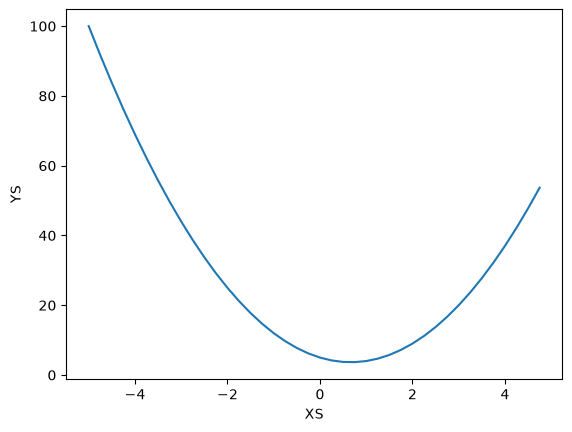

In [297]:
plt.plot(xs,ys)
plt.xlabel("XS")
plt.ylabel("YS")

In [298]:
h = 0.000001
x = 2/3
(f(x+h)-f(x))/h

2.999378523327323e-06

In [299]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [300]:
a = 2.0
b = -3.0
c = 10.0

d1 = a*b +c
c+= h
d2 = a*b+c

print(f"d1:      {d1},\nd2:      {d2}")
print('slope :',(d2-d1)/h)

d1:      4.0,
d2:      4.000000999999999
slope : 0.9999999992515995


In [301]:
class value:
    def __init__(self,data,_children=(),_op= '',label = ''):
        self.data = data
        self.grad = 0.0
        self._backwards = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value (Data = {self.data})"
    def __add__(self,other):
        out = value(self.data+ other.data,(self,other),'+')
        def _backwards():
            self.grad  += out.grad
            other.grad += out.grad
        out._backwards = _backwards

        return out
    def __mul__(self,other):
            out = value(self.data* other.data,(self,other),'*')
            def _backwards():
                self.grad  += other.data*out.grad
                other.grad += self.data*out.grad
            out._backwards = _backwards
            return out
    def tanh(self):
        x = self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = value (t,(self,),'tanh')
        def _backwards():
            self.grad += (1-t**2)*out.grad
        out._backwards = _backwards
        return out
         

In [302]:
a = value(2.0, label = 'a')
b = value(-3.0, label = 'b')
c =value(10.0, label = 'c')
e = a*b; e.label = 'e'
d =e+c;d.label = 'd'
f = value(-2.0,label = 'f')
L = d*f;L.label= 'L'

print(d)
print(d._prev)
print(L)

Value (Data = 4.0)
{Value (Data = -6.0), Value (Data = 10.0)}
Value (Data = -8.0)


In [303]:
print(d._op,", ",d)

+ ,  Value (Data = 4.0)


In [304]:
from graphviz import Digraph
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges
def draw_dot(root):
    dot = Digraph(format = 'svg',graph_attr = {'rankdir':'LR'})
    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid,label ="{%s | data %.4f | grad %.4f}"%(n.label,n.data,n.grad),shape= 'record')
        if n._op:
            dot.node(name = uid+n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot



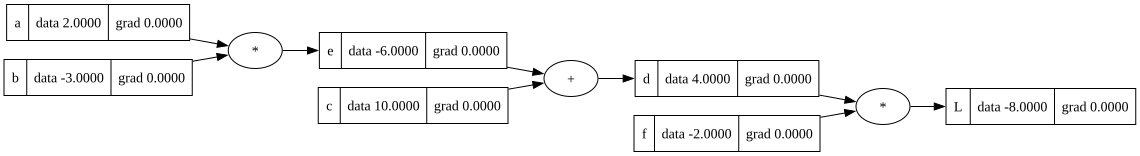

In [305]:
draw_dot(L)

In [306]:
# f.grad = 4.0
# d.grad= -2.0
# c.grad = -2.0
# e.grad = -2.0
# a.grad = 6.0
# b.grad = -4.0

In [307]:
a = value(2.0, label = 'a')
b = value(-3.0, label = 'b')
c =value(10.0, label = 'c')
f = value(-2.0,label = 'f')

In [308]:
f.grad = 4.0
d.grad= -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0

In [309]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a*b
    # e.data+=h
d =e+c
    # d.data += h 

L = d*f
print(L.data)

-7.286496


In [310]:
def lol():
    h = 0.001
    a = value(2.0, label = 'a')
    b = value(-3.0, label = 'b')
    c =value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d =e+c;d.label = 'd'
    f = value(-2.0,label = 'f')
    L = d*f;L.label= 'L'
    L1 = L.data

    a = value(2.0, label = 'a')
    # a.data+= h
    b = value(-3.0, label = 'b')
    # b.data += h
    c =value(10.0, label = 'c')
    # c.data+=h
    e = a*b; e.label = 'e'
    # e.data+=h
    d =e+c;d.label = 'd'
    # d.data += h 
    f = value(-2.0,label = 'f')
    L = d*f;L.label= 'L'
    L2 = L.data

    return ((L2-L1)/h)
lol()

0.0

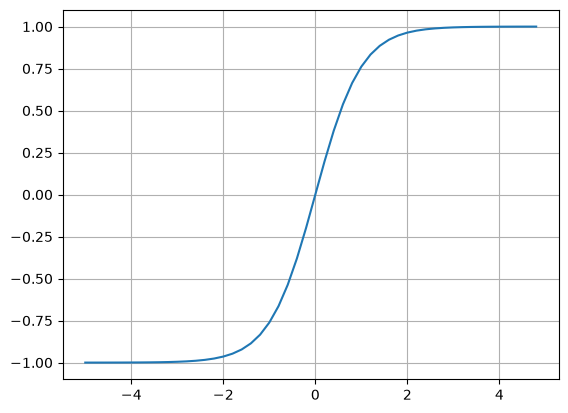

In [311]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [312]:
x1 = value(2.0,label = 'x1')
x2 = value(0.0,label = 'x2')
w1 = value(-3.0,label = 'w1')
w2 = value(1.0, label = 'w2')

b = value(6.88137,label = 'b')
x1w1 = x1*w1;x1w1.label = 'x1w1'
x2w2 = x2*w2;x2w2.label = 'x2w2'
x1w1x2w2 = x1w1+x2w2;x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 +b
o = n.tanh();o.label = 'o'
n.label= 'n'

In [313]:
# k = value()
# k2  = k.tanh()
# print(k2)

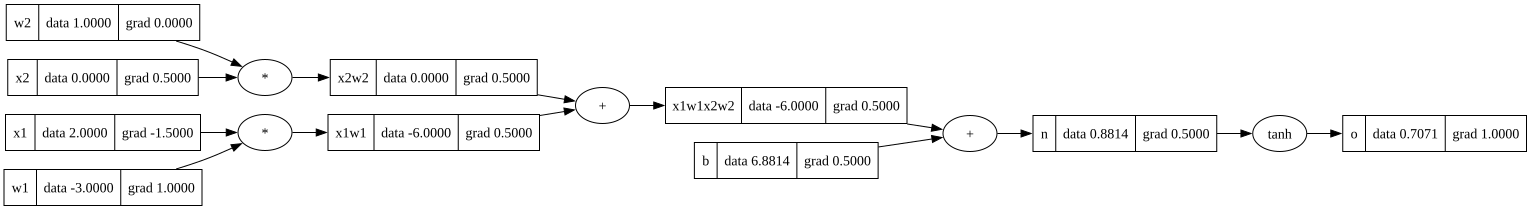

In [326]:
draw_dot(o)

In [315]:
o.grad= 1

In [316]:
o._backwards()

In [317]:
n._backwards()

In [318]:
b._backwards()

In [319]:




x1w1x2w2._backwards()

In [320]:
x2w2._backwards()

In [321]:
x1w1._backwards()

In [322]:
# n.grad = 0.50000 
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# o.grad = 1.0
# x1w1.grad= 0.5
# x2w2.grad = 0.5

In [323]:
# o = tanh(n)
# do/dn = 1-o**2


In [324]:
# 1- o.data**2

In [325]:
# x2.grad = w2.data*x2w2.grad
# w2.grad = x2.data*x2w2.grad
# x1.grad = w1.data*x1w1.grad
# w1.grad = x1.data*x1w1.grad